# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1782999354380.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-02 09:30:14 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,MSFT,$383.99,0.026040,COMPLETE,$10 Purchase of Microsoft,NaN,Cash Balance
1,2026-07-02 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$778.00,0.012850,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
2,2026-07-02 09:30:12 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,INTU,$269.90,0.037050,COMPLETE,$10 Purchase of Intuit,NaN,Cash Balance
3,2026-07-02 09:30:09 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,GOOG,$356.89,0.028010,COMPLETE,$10 Purchase of Alphabet Inc. Class C,NaN,Cash Balance
4,2026-07-02 09:30:07 EDT,NaN,NaN,USD,$20.89,$0.00,$20.89,ALKT,$18.81,1.110770,COMPLETE,$20.89 Sale of Alkami Technology,NaN,Cash Balance
5,2026-07-02 09:30:06 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,TGT,$130.74,0.076480,COMPLETE,$10 Sale of Target,NaN,Cash Balance
6,2026-07-02 09:30:05 EDT,NaN,NaN,USD,$11.36,$0.00,$11.36,ILMN,$185.00,0.061390,COMPLETE,$11.36 Sale of Illumina,NaN,Cash Balance
7,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.093490,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
8,2026-07-02 09:30:02 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,JEPI,$56.33,0.177520,COMPLETE,$10 Purchase of JPMorgan Equity Premium Income...,NaN,Cash Balance
9,2026-07-02 09:30:00 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BSV,$77.71,0.128680,COMPLETE,$10 Purchase of Vanguard Short Term Bond ETF,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
106,2026-06-22 09:30:04 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,AMAT,$626.22,0.00798,COMPLETE,$5 Sale of Applied Materials,NaN,Cash Balance
243,2026-06-08 12:38:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,JPM,$312.37,0.06402,COMPLETE,$20 Sale of JPMorgan Chase,NaN,Cash Balance
90,2026-06-22 09:30:48 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$313.48,0.03189,COMPLETE,$10 Sale of Marvell Technology,NaN,Cash Balance
82,2026-06-22 13:16:52 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$33.58,0.29775,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
6,2026-07-02 09:30:05 EDT,NaN,NaN,USD,$11.36,$0.00,$11.36,ILMN,$185.00,0.06139,COMPLETE,$11.36 Sale of Illumina,NaN,Cash Balance
139,2026-06-18 10:10:06 EDT,NaN,NaN,USD,$3.00,$0.00,$3.00,EBAY,$109.56,0.02738,COMPLETE,$3 Sale of eBay,NaN,Cash Balance
280,2026-06-04 09:30:07 EDT,NaN,NaN,USD,$10.21,$0.00,$10.21,OWL,$9.79,1.04329,COMPLETE,$10.21 Sale of Blue Owl Capital,NaN,Cash Balance
4,2026-07-02 09:30:07 EDT,NaN,NaN,USD,$20.89,$0.00,$20.89,ALKT,$18.81,1.11077,COMPLETE,$20.89 Sale of Alkami Technology,NaN,Cash Balance
36,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
92,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.02604
1      0.01285
2      0.03705
3      0.02801
4      1.11077
        ...   
653        NaN
654        NaN
655        NaN
656        NaN
657        NaN
Name: Asset Amount, Length: 658, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
485,2026-06-02 19:54:00+00:00,-1.0,-0.98,67817.91,0.000014,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001445,NaN
337,2026-06-03 19:22:37+00:00,-10.0,-10.00,69.87,0.143120,0.00,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
253,2026-06-08 16:30:32+00:00,-10.0,-10.00,82.12,0.121770,0.00,NFLX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Netflix,NaN
246,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
243,2026-06-08 16:38:52+00:00,20.0,20.00,312.37,0.064020,0.00,JPM,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$20 Sale of JPMorgan Chase,NaN
167,2026-06-16 13:32:08+00:00,-10.0,-10.00,189.00,0.052910,0.00,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Oracle,NaN
157,2026-06-16 15:45:00+00:00,-5.0,-5.00,68.25,0.073260,0.00,EEFT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Euronet,NaN
96,2026-06-22 13:30:19+00:00,10.0,10.00,84.50,0.118340,0.00,DAL,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Delta Air Lines,NaN
89,2026-06-22 13:30:49+00:00,-10.0,-10.00,545.43,0.018330,0.00,AMD,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Advanced Micro Devices,NaN
62,2026-06-26 04:00:00+00:00,0.3,0.30,NaN,0.000000,0.00,VFH,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.30 Dividend from Vanguard Financials ETF,NaN


In [6]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
651,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
652,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
653,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
655,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
656,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
657,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


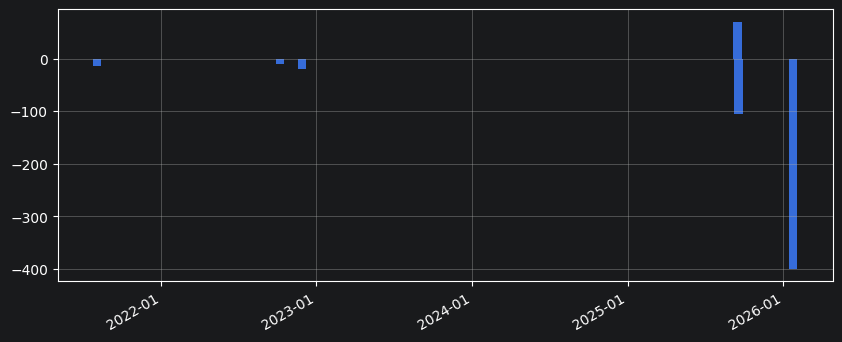

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [8]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,658.000000,658.000000,536.000000,658.000000,655.000000
mean,0.091277,0.100760,3963.497108,0.144321,-0.009527
std,38.177314,38.174999,15867.079516,0.337396,0.053349
min,-400.000000,-400.000000,2.220000,0.000000,-0.500000
25%,-10.000000,-10.000000,55.920000,0.009520,0.000000
50%,-10.000000,-10.000000,130.280000,0.046045,0.000000
75%,-1.000000,-1.000000,300.160000,0.127965,0.000000
max,200.000000,200.000000,80346.140000,4.509170,0.000000


In [9]:
data.nunique().sort_values(ascending=False)

asset_price     527
asset_amount    524
date            517
notes           380
asset_type      167
amount           59
net_amount       58
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [63]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      29
XYZ      13
JPM      12
WFC      11
MCD      10
AMZN     10
META     10
PZZA     10
ORCL     10
V         9
MSFT      8
GOOG      8
VONV      8
GOOGL     8
UBER      8
FISV      7
HOOD      7
DOW       7
INTU      6
PYPL      6
VOO       6
PD        6
DELL      6
VFH       6
VMBS      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

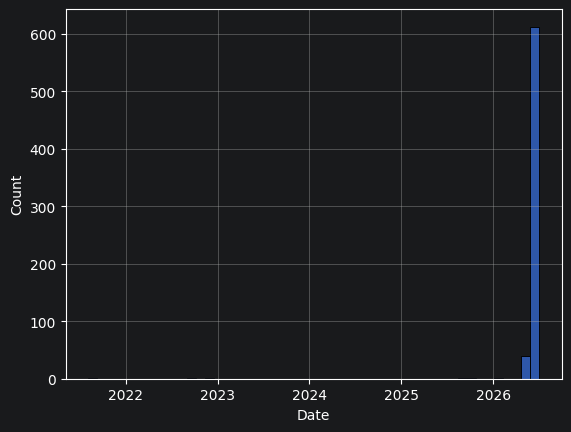

In [11]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [12]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-03-25,2026-05-27,2026-05-29,2026-06-02,2026-06-03,2026-06-16,2026-06-26,2026-07-01,2026-07-02


In [13]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,29,-186.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,13,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,11,-51.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
ORCL,10,-85.00,"(-10.0, -5.0)",2
META,10,-70.95,"(-10.0, -5.0, -1.0, 0.05)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
AMZN,10,-161.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4


In [14]:
data['currency'].value_counts()

currency
USD    658
Name: count, dtype: int64

In [15]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    464
Deposits                      65
Stock Sell                    43
Stock Dividends               35
Bitcoin Buy                   24
Savings Internal Transfer     12
P2P                            6
Bitcoin Sell                   5
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,5,464,35,43,571
BTC,24,5,0,0,0,29
XYZ,0,0,12,0,1,13
JPM,0,0,10,0,2,12
WFC,0,0,9,0,2,11
META,0,0,9,1,0,10
ORCL,0,0,10,0,0,10
PZZA,0,0,9,0,1,10
AMZN,0,0,10,0,0,10


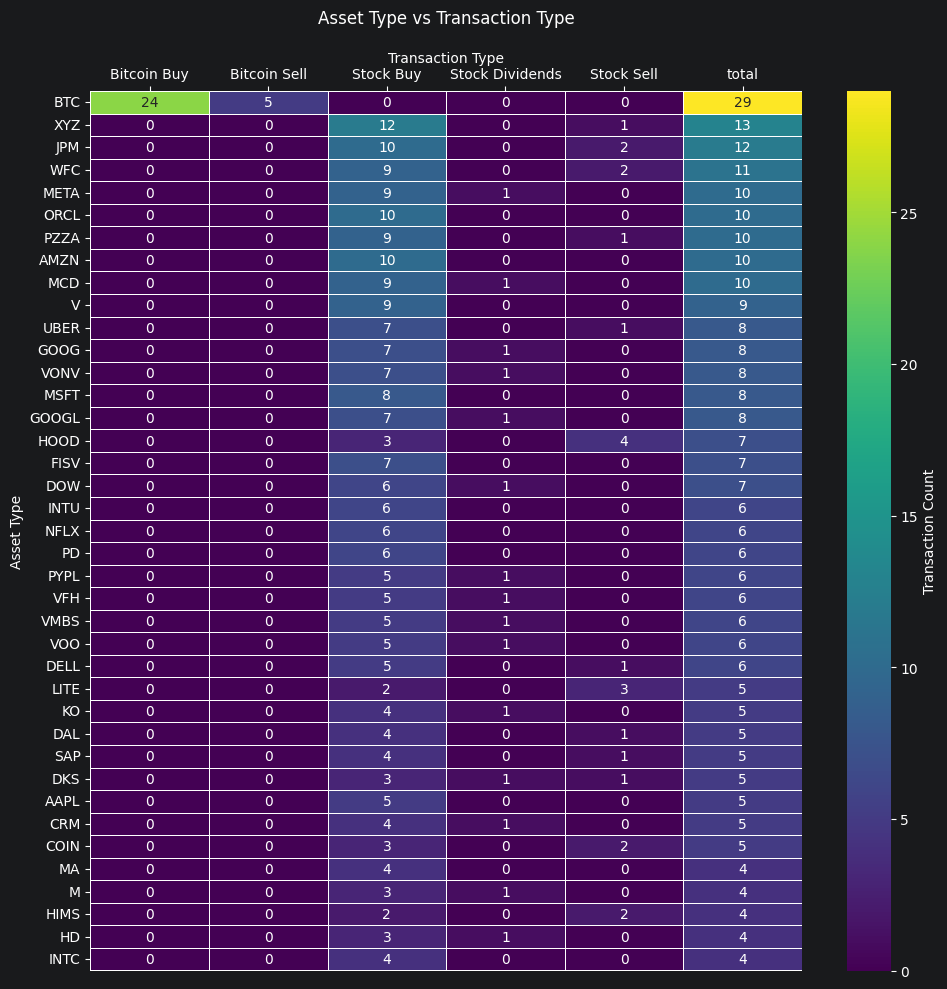

In [17]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [18]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
21,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
58,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN
113,2026-06-20 20:54:15+00:00,9.8,10.0,63371.65,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
115,2026-06-20 11:51:40+00:00,-5.0,-4.9,64191.63,0.000076,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN
124,2026-06-18 17:13:37+00:00,19.6,20.0,61888.37,0.000323,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032316,NaN


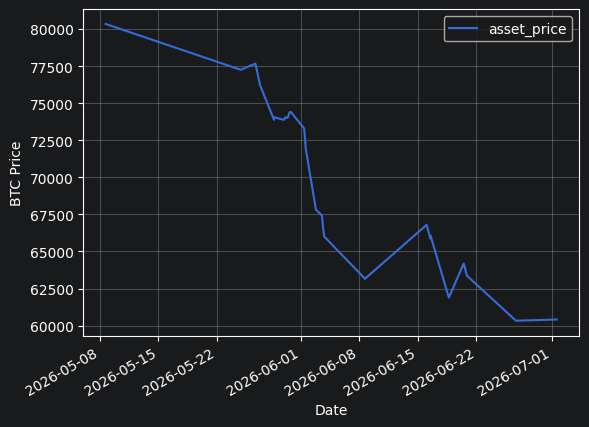

In [19]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [20]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     5
Name: count, dtype: int64

In [21]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,58.8


In [22]:
data_btc['net_amount'].sum()

np.float64(-193.2)

In [23]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.000949
Name: asset_amount, dtype: float64

In [24]:
data_btc['asset_amount'].sum()

np.float64(0.0043688)

In [25]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00247044)

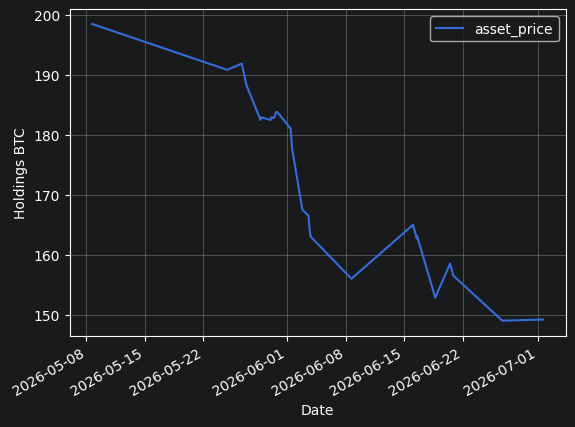

In [26]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [27]:
data_btc['asset_price'] * data_btc['asset_amount']

21      9.800290
58      4.900090
113    10.000046
115     4.899747
124    19.999846
206     5.000156
207     4.999899
210     4.900240
246    19.999798
326     9.799846
353     9.800287
377     0.980144
474     9.800221
485     0.979969
502     9.799652
560     4.900136
562     9.799865
565     4.900112
566     9.799903
570     9.799965
574    24.500200
581    24.499951
585    24.500084
604     9.799731
608     9.800031
631    24.499991
648     9.799898
649     4.900356
650     9.799819
dtype: float64

In [28]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
57,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
86,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
168,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
213,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
261,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
337,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
349,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
362,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
400,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
403,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN


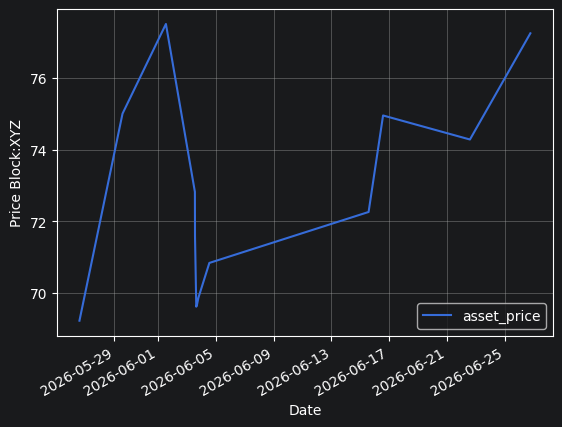

In [29]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [30]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     29
XYZ     13
JPM     12
WFC     11
ORCL    10
        ..
SLAB     1
SNAP     1
BSV      1
TMO      1
ZG       1
Name: amount, Length: 167, dtype: int64

In [31]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [32]:
data['asset_amount'].describe()

count    658.000000
mean       0.144321
std        0.337396
min        0.000000
25%        0.009520
50%        0.046045
75%        0.127965
max        4.509170
Name: asset_amount, dtype: float64

In [33]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 14:17:27+00:00,47.937087,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,27.762524,0.0,181.056739,42.997334,19.954137,9.999727,9.999925
2026-06-22 13:30:00+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,19.954137,9.999727,9.999925
2026-06-02 19:54:00+00:00,10.217560,0.000000,0.000000,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,0.000000,19.992722,0.0,93.073427,0.000000,0.000000,0.000000,0.000000
2026-06-15 13:30:29+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,27.762524,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:11+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-07-01 04:00:00+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,26.856968,75.498388,23.724046,27.762524,0.0,181.056739,42.997334,19.954137,9.999727,9.999925
2026-06-02 18:14:25+00:00,10.217560,0.000000,0.000000,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,0.000000,19.992722,0.0,93.073427,0.000000,0.000000,0.000000,0.000000
2026-06-22 13:33:17+00:00,37.937295,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,0.000000,75.407448,23.724046,27.762524,0.0,171.057249,42.997334,19.954137,9.999727,9.999925
2026-05-27 13:30:01+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000


In [34]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3736.0790344)

In [35]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 13:30:07+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:09+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:12+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:13+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:14+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677


In [36]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.007147
min        0.000000
25%        0.002676
50%        0.004137
75%        0.006721
max        0.048462
Name: 2026-07-02 13:30:14+00:00, dtype: float64

In [37]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.048462
AMZN    0.040046
V       0.027883
MCD     0.026233
UBER    0.025740
Name: 2026-07-02 13:30:14+00:00, dtype: float64

In [38]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 13:30:07+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:09+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:12+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:13+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677
2026-07-02 13:30:14+00:00,0.012831,0.002676,0.004331,0.002676,0.0,0.002676,0.0,0.005634,0.00242,0.008048,...,0.001837,0.014855,0.00635,0.010107,0.0,0.048462,0.014185,0.005341,0.002677,0.002677


In [39]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 15:28:14+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-08 16:29:25+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-24 13:31:03+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:32:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,72.26,NaN,NaN,NaN,NaN
2026-06-03 19:37:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 19:14:17+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 18:53:08+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:24+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 15:28:14+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-08 16:29:25+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-24 13:31:03+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.072945,1.005550,0.995338,1.0,1.0
2026-06-15 13:32:07+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-03 19:37:04+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016406,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-16 19:14:17+00:00,1.018386,1.0,0.901125,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-15 18:53:08+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-15 13:30:24+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-01 13:30:10+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

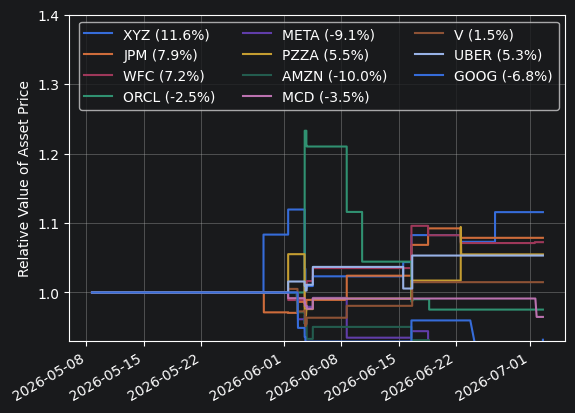

In [41]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [42]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-02 13:30:07+00:00    1.115701
2026-07-02 13:30:09+00:00    1.115701
2026-07-02 13:30:12+00:00    1.115701
2026-07-02 13:30:13+00:00    1.115701
2026-07-02 13:30:14+00:00    1.115701
Name: XYZ, Length: 414, dtype: float64

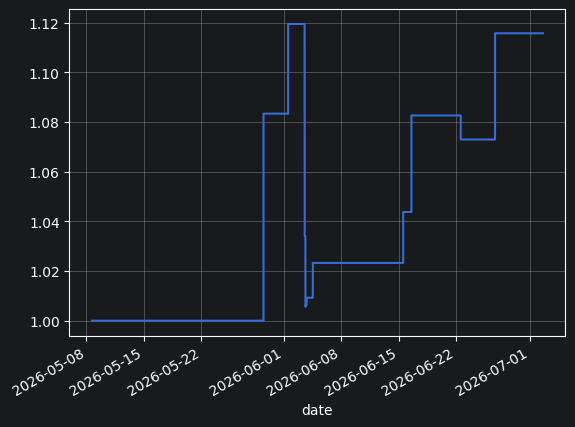

In [43]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [44]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

,date,amount,asset_type,notes
11,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
47,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
48,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
49,2026-07-01,0.09,M,$0.09 Dividend from Macy's
50,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing
51,2026-07-01,0.12,PSKY,$0.12 Dividend from Paramount Skydance
52,2026-06-30,0.01,AVGO,$0.01 Dividend from Broadcom
53,2026-06-30,0.14,VBR,$0.14 Dividend from Small Cap Value ETF Vanguard
54,2026-06-30,0.02,GSLC,$0.02 Dividend from Goldman Sachs ActiveBeta U...
55,2026-06-30,0.07,VOO,$0.07 Dividend from Vanguard S&P 500 ETF


In [45]:
div_data['amount'].sum()

np.float64(3.57)

In [46]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
62,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
47,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
69,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
65,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
208,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
59,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
48,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
60,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
79,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
50,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


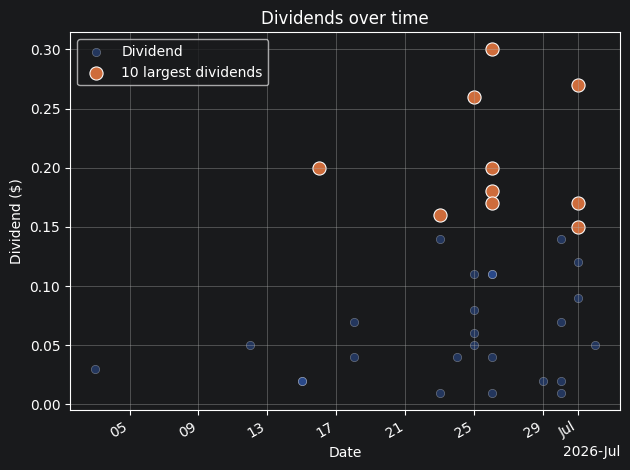

In [47]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [48]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
65,2026-06-26 04:00:00+00:00,0.20,NaN,$0.20 Dividend from Energy ETF Vanguard,VDE
442,2026-06-03 13:30:09+00:00,-10.00,272.44,$10 Purchase of Vanguard Health Care ETF,VHT
77,2026-06-23 04:00:00+00:00,0.01,NaN,$0.01 Dividend from Vanguard Russell 1000 Grow...,VONG
390,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
9,2026-07-02 13:30:00+00:00,-10.00,77.71,$10 Purchase of Vanguard Short Term Bond ETF,BSV
300,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT
533,2026-06-01 13:30:16+00:00,-25.00,160.89,$25 Purchase of Energy ETF Vanguard,VDE
363,2026-06-03 15:49:42+00:00,-10.00,124.12,$10 Purchase of Vanguard Financials ETF,VFH
63,2026-06-26 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Health Care ETF,VHT
78,2026-06-23 04:00:00+00:00,0.14,NaN,$0.14 Dividend from Vanguard Russell 1000 Valu...,VONV


In [49]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    8
VOO     6
VFH     6
VMBS    6
VNQ     4
VHT     4
VDE     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
BIV     2
VTEB    2
VGLT    2
BNDX    2
BSV     1
Name: count, dtype: int64

In [50]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
65,2026-06-26 04:00:00+00:00,0.20,NaN,VDE,NaN
442,2026-06-03 13:30:09+00:00,-10.00,272.44,VHT,Vanguard Health Care ETF
77,2026-06-23 04:00:00+00:00,0.01,NaN,VONG,NaN
390,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
9,2026-07-02 13:30:00+00:00,-10.00,77.71,BSV,Vanguard Short Term Bond ETF
300,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF
533,2026-06-01 13:30:16+00:00,-25.00,160.89,VDE,Energy ETF Vanguard
363,2026-06-03 15:49:42+00:00,-10.00,124.12,VFH,Vanguard Financials ETF
63,2026-06-26 04:00:00+00:00,0.11,NaN,VHT,NaN
78,2026-06-23 04:00:00+00:00,0.14,NaN,VONV,NaN


In [51]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                7
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VOO         Vanguard S&P 500 ETF                           5
VFH         Vanguard Financials ETF                        5
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            2
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
VGLT        Vanguard Long-Treasury ETF                     2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VCR         Vanguard Consumer Discretionary ETF            2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [52]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VFH,VMBS,VNQ,VHT,VDE,VSS,VBR,VCR,VDC,VONG,BIV,VTEB,VGLT,BNDX,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
vanguard_trans_count

asset_type
VONV    8
VOO     6
VFH     6
VMBS    6
VNQ     4
VHT     4
VDE     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
BIV     2
VTEB    2
VGLT    2
BNDX    2
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

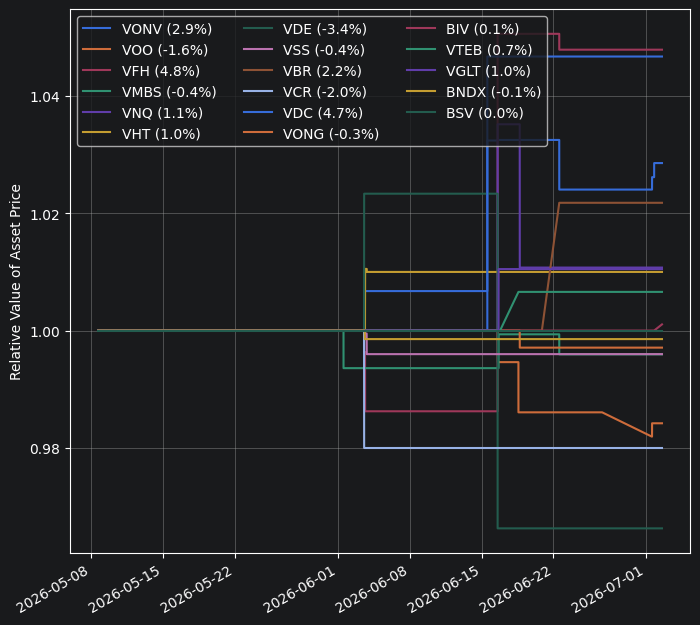

In [54]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
12,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
37,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
112,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
114,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
125,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
642,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
643,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
644,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
645,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [56]:
data_deposits['net_amount'].sum()

np.float64(5735.96)

In [57]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,65.0,88.245538,49.961254,1.0,50.0,100.0,100.0,200.0


In [58]:
data_deposits['net_amount'].cumsum()

12      100.00
37      200.00
112     300.00
114     400.00
125     500.00
        ...   
642    5630.96
643    5640.96
644    5690.96
645    5710.96
646    5735.96
Name: net_amount, Length: 65, dtype: float64

In [59]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
646,2026-05-26 19:39:34+00:00,25.00
645,2026-05-26 21:58:29+00:00,45.00
644,2026-05-27 00:43:01+00:00,95.00
643,2026-05-27 00:56:05+00:00,105.00
642,2026-05-27 00:56:27+00:00,205.00
...,...,...
125,2026-06-18 17:13:20+00:00,5335.96
114,2026-06-20 12:23:07+00:00,5435.96
112,2026-06-21 21:31:19+00:00,5535.96
37,2026-07-01 13:41:36+00:00,5635.96


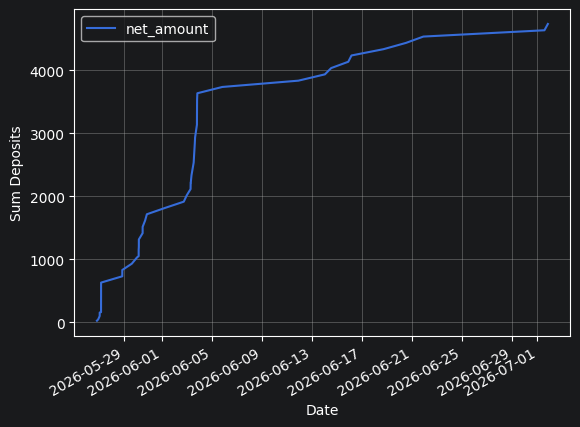

In [60]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [61]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [62]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4400.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64